### Overview

Building upon the previous capstone work, which focused on data aggregation, cleaning, processing, and visualization, this phase aims to develop machine learning models to predict hourly bike rental counts. The project will cover feature engineering, scaling, and regression modeling techniques to build an effective predictive model.

---

### Project Statement

**Develop an end-to-end machine learning pipeline to forecast hourly bike rentals using various regression techniques and performance evaluation methods.**

---

### Tasks

#### **Task 1: Feature Engineering (45 mins)**

**Input dataset:** Use your preprocessed/engineered dataset from Task 1: feature engineering (original dataset [here](https://github.com/gperdrizet/FSA_devops/blob/main/data/unit3/FloridaBikeRentals.csv)).

- Analyze the provided dataset and select relevant features.
- Create new features such as:  
    - Normalized ('ratio') features  
    - Difference features  
    - Other transformed features (log, square root, etc.)  
    - Anything else interesting you can dream up  
- Encode categorical variables and handle missing values.
- Scale the numerical features using `StandardScaler`.
- Save the processed dataset as **"bike_rental_features.csv"**.

---

#### **Task 2: Model Building (75 mins)**

- Implement various regression models including:  
    - Linear Regression  
    - Ridge Regression (L2 Regularization)  
    - Lasso Regression (L1 Regularization)  
    - Elastic Net Regression  
- Perform hyperparameter tuning using `GridSearchCV`.
- Evaluate model performance using:  
    - Mean Absolute Error (MAE)  
    - Mean Squared Error (MSE)  
    - R-squared (R²)  

---

#### **Task 3: Model Building with Polynomial Features (45 mins)**

- Create polynomial features for selected numerical columns.
- Train models with polynomial features to capture non-linear relationships.
- Compare results with linear models to assess improvements.
- Save the best-performing model.

---

#### **Task 4: Model Evaluation and Validation (45 mins)**

- Perform cross-validation techniques to validate model performance (on both models - With Polynomial Features and Without Polynomial Features).
- Assess models using test data.
- Compare results across different regression models.
- Summarize findings and key takeaways from the analysis.
- Discuss feature importance and business implications.
- Provide recommendations for further improvements.


### Task 1 Feature Engineering ###
- Analyze the provided dataset and select relevant features.
- Create new features such as:  
    - Normalized ('ratio') features  
    - Difference features  
    - Other transformed features (log, square root, etc.)  
    - Anything else interesting you can dream up  
- Encode categorical variables and handle missing values.
- Scale the numerical features using `StandardScaler`.
- Save the processed dataset as **"bike_rental_features.csv"**.

In [61]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer


fbr_df = pd.read_csv('FloridaBikeRentals.csv')
# Display the first few rows of the dataset
print(fbr_df.head().to_string())

print(fbr_df.info())
print(fbr_df.describe().to_string())
# Print categorical columns' unique values
categorical_cols = fbr_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Unique values in '{col}': {fbr_df[col].unique()}")

         Date  Rented Bike Count  Hour  Temperature(C)  Humidity(%)  Wind speed (m/s)  Visibility (10m)  Dew point temperature(C)  Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday Functioning Day
0  01/12/2017                254     0            -5.2           37               2.2              2000                     -17.6                      0.0           0.0            0.0  Winter  No Holiday             Yes
1  01/12/2017                204     1            -5.5           38               0.8              2000                     -17.6                      0.0           0.0            0.0  Winter  No Holiday             Yes
2  01/12/2017                173     2            -6.0           39               1.0              2000                     -17.7                      0.0           0.0            0.0  Winter  No Holiday             Yes
3  01/12/2017                107     3            -6.2           40               0.9              2000                 

In [62]:
# rename dataframe columns to lowercase
fbr_df.columns = fbr_df.columns.str.lower()
# rename dataframe columns to replace spaces with underscores (snake case)
fbr_df.columns = fbr_df.columns.str.replace(' ', '_')
# Remove any underscore in the column name if before a paranthesis
fbr_df.columns = fbr_df.columns.str.replace('_(', '(', regex=False)

# Resize dtypes to optimize memory usage
for col in fbr_df.columns:
    if fbr_df[col].dtype == 'float64':
        fbr_df[col] = pd.to_numeric(fbr_df[col], downcast='float')
    elif fbr_df[col].dtype == 'int64':
        fbr_df[col] = pd.to_numeric(fbr_df[col], downcast='integer')
# Change date column to datetime type for day/month/year extraction
fbr_df['date'] = pd.to_datetime(fbr_df['date'], format='%d/%m/%Y')
# Change yes/no columns to use boolean type
fbr_df['holiday'] = fbr_df['holiday'].map({'Holiday': True, 'No Holiday': False}).astype('boolean')
fbr_df['functioning_day'] = fbr_df['functioning_day'].map({'Yes': True, 'No': False}).astype('boolean')
# One hot encode seasons
# This drops seasons_Autumn to avoid the dummy variable trap <- Ask about in class: copilot wrote the comment before I turned it off and I wasn't sure what it meant
fbr_df = pd.get_dummies(fbr_df, columns=['seasons'], drop_first=True)
# Break up date into multiple features
fbr_df['year'] = fbr_df['date'].dt.year.astype('int16')
fbr_df['month'] = fbr_df['date'].dt.month.astype('int8')
fbr_df['day'] = fbr_df['date'].dt.day.astype('int8')
# Drop original date column
fbr_df = fbr_df.drop(columns=['date'])

# Display updated dataframe info
print(fbr_df.info())
print(fbr_df.describe().to_string())
# Save cleaned dataframe to new CSV file
fbr_df.to_csv('bike_rental_features.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rented_bike_count         8760 non-null   int16  
 1   hour                      8760 non-null   int8   
 2   temperature(c)            8760 non-null   float32
 3   humidity(%)               8760 non-null   int8   
 4   wind_speed(m/s)           8760 non-null   float32
 5   visibility(10m)           8760 non-null   int16  
 6   dew_point_temperature(c)  8760 non-null   float32
 7   solar_radiation(mj/m2)    8760 non-null   float32
 8   rainfall(mm)              8760 non-null   float32
 9   snowfall(cm)              8760 non-null   float32
 10  holiday                   8760 non-null   boolean
 11  functioning_day           8760 non-null   boolean
 12  seasons_Spring            8760 non-null   bool   
 13  seasons_Summer            8760 non-null   bool   
 14  seasons_

In [63]:
# Scale numerical features using sklearn's standard scaler
# Leaving out day, month, and year. If this becomes an issue maybe change them later, or ask in class
# Don't scale rented_bike_count as that is the target variable
numerical_features = ['temperature(c)',
                      'humidity(%)',
                      'wind_speed(m/s)',
                      'visibility(10m)',
                      'dew_point_temperature(c)',
                      'solar_radiation(mj/m2)',
                      'rainfall(mm)',
                      'snowfall(cm)']

scaler = StandardScaler()
scaled_fbr_df = fbr_df.copy()
scaled_fbr_df[numerical_features] = scaler.fit_transform(fbr_df[numerical_features])

# Print scaled descriptions
print(scaled_fbr_df.head().to_string())
print(scaled_fbr_df.info())
print(scaled_fbr_df.describe().to_string())

   rented_bike_count  hour  temperature(c)  humidity(%)  wind_speed(m/s)  visibility(10m)  dew_point_temperature(c)  solar_radiation(mj/m2)  rainfall(mm)  snowfall(cm)  holiday  functioning_day  seasons_Spring  seasons_Summer  seasons_Winter  year  month  day
0                254     0       -1.513957    -1.042483         0.458476         0.925871                 -1.659605               -0.655132       -0.1318     -0.171891    False             True           False           False            True  2017     12    1
1                204     1       -1.539074    -0.993370        -0.892561         0.925871                 -1.659605               -0.655132       -0.1318     -0.171891    False             True           False           False            True  2017     12    1
2                173     2       -1.580936    -0.944257        -0.699556         0.925871                 -1.667262               -0.655132       -0.1318     -0.171891    False             True           False           

### Task 2 Model Building ###
- Implement various regression models including:  
    - Linear Regression  
    - Ridge Regression (L2 Regularization)  
    - Lasso Regression (L1 Regularization)  
    - Elastic Net Regression  
- Perform hyperparameter tuning using `GridSearchCV`.
- Evaluate model performance using:  
    - Mean Absolute Error (MAE)  
    - Mean Squared Error (MSE)  
    - R-squared (R²)  

3.10.7
0.13.2


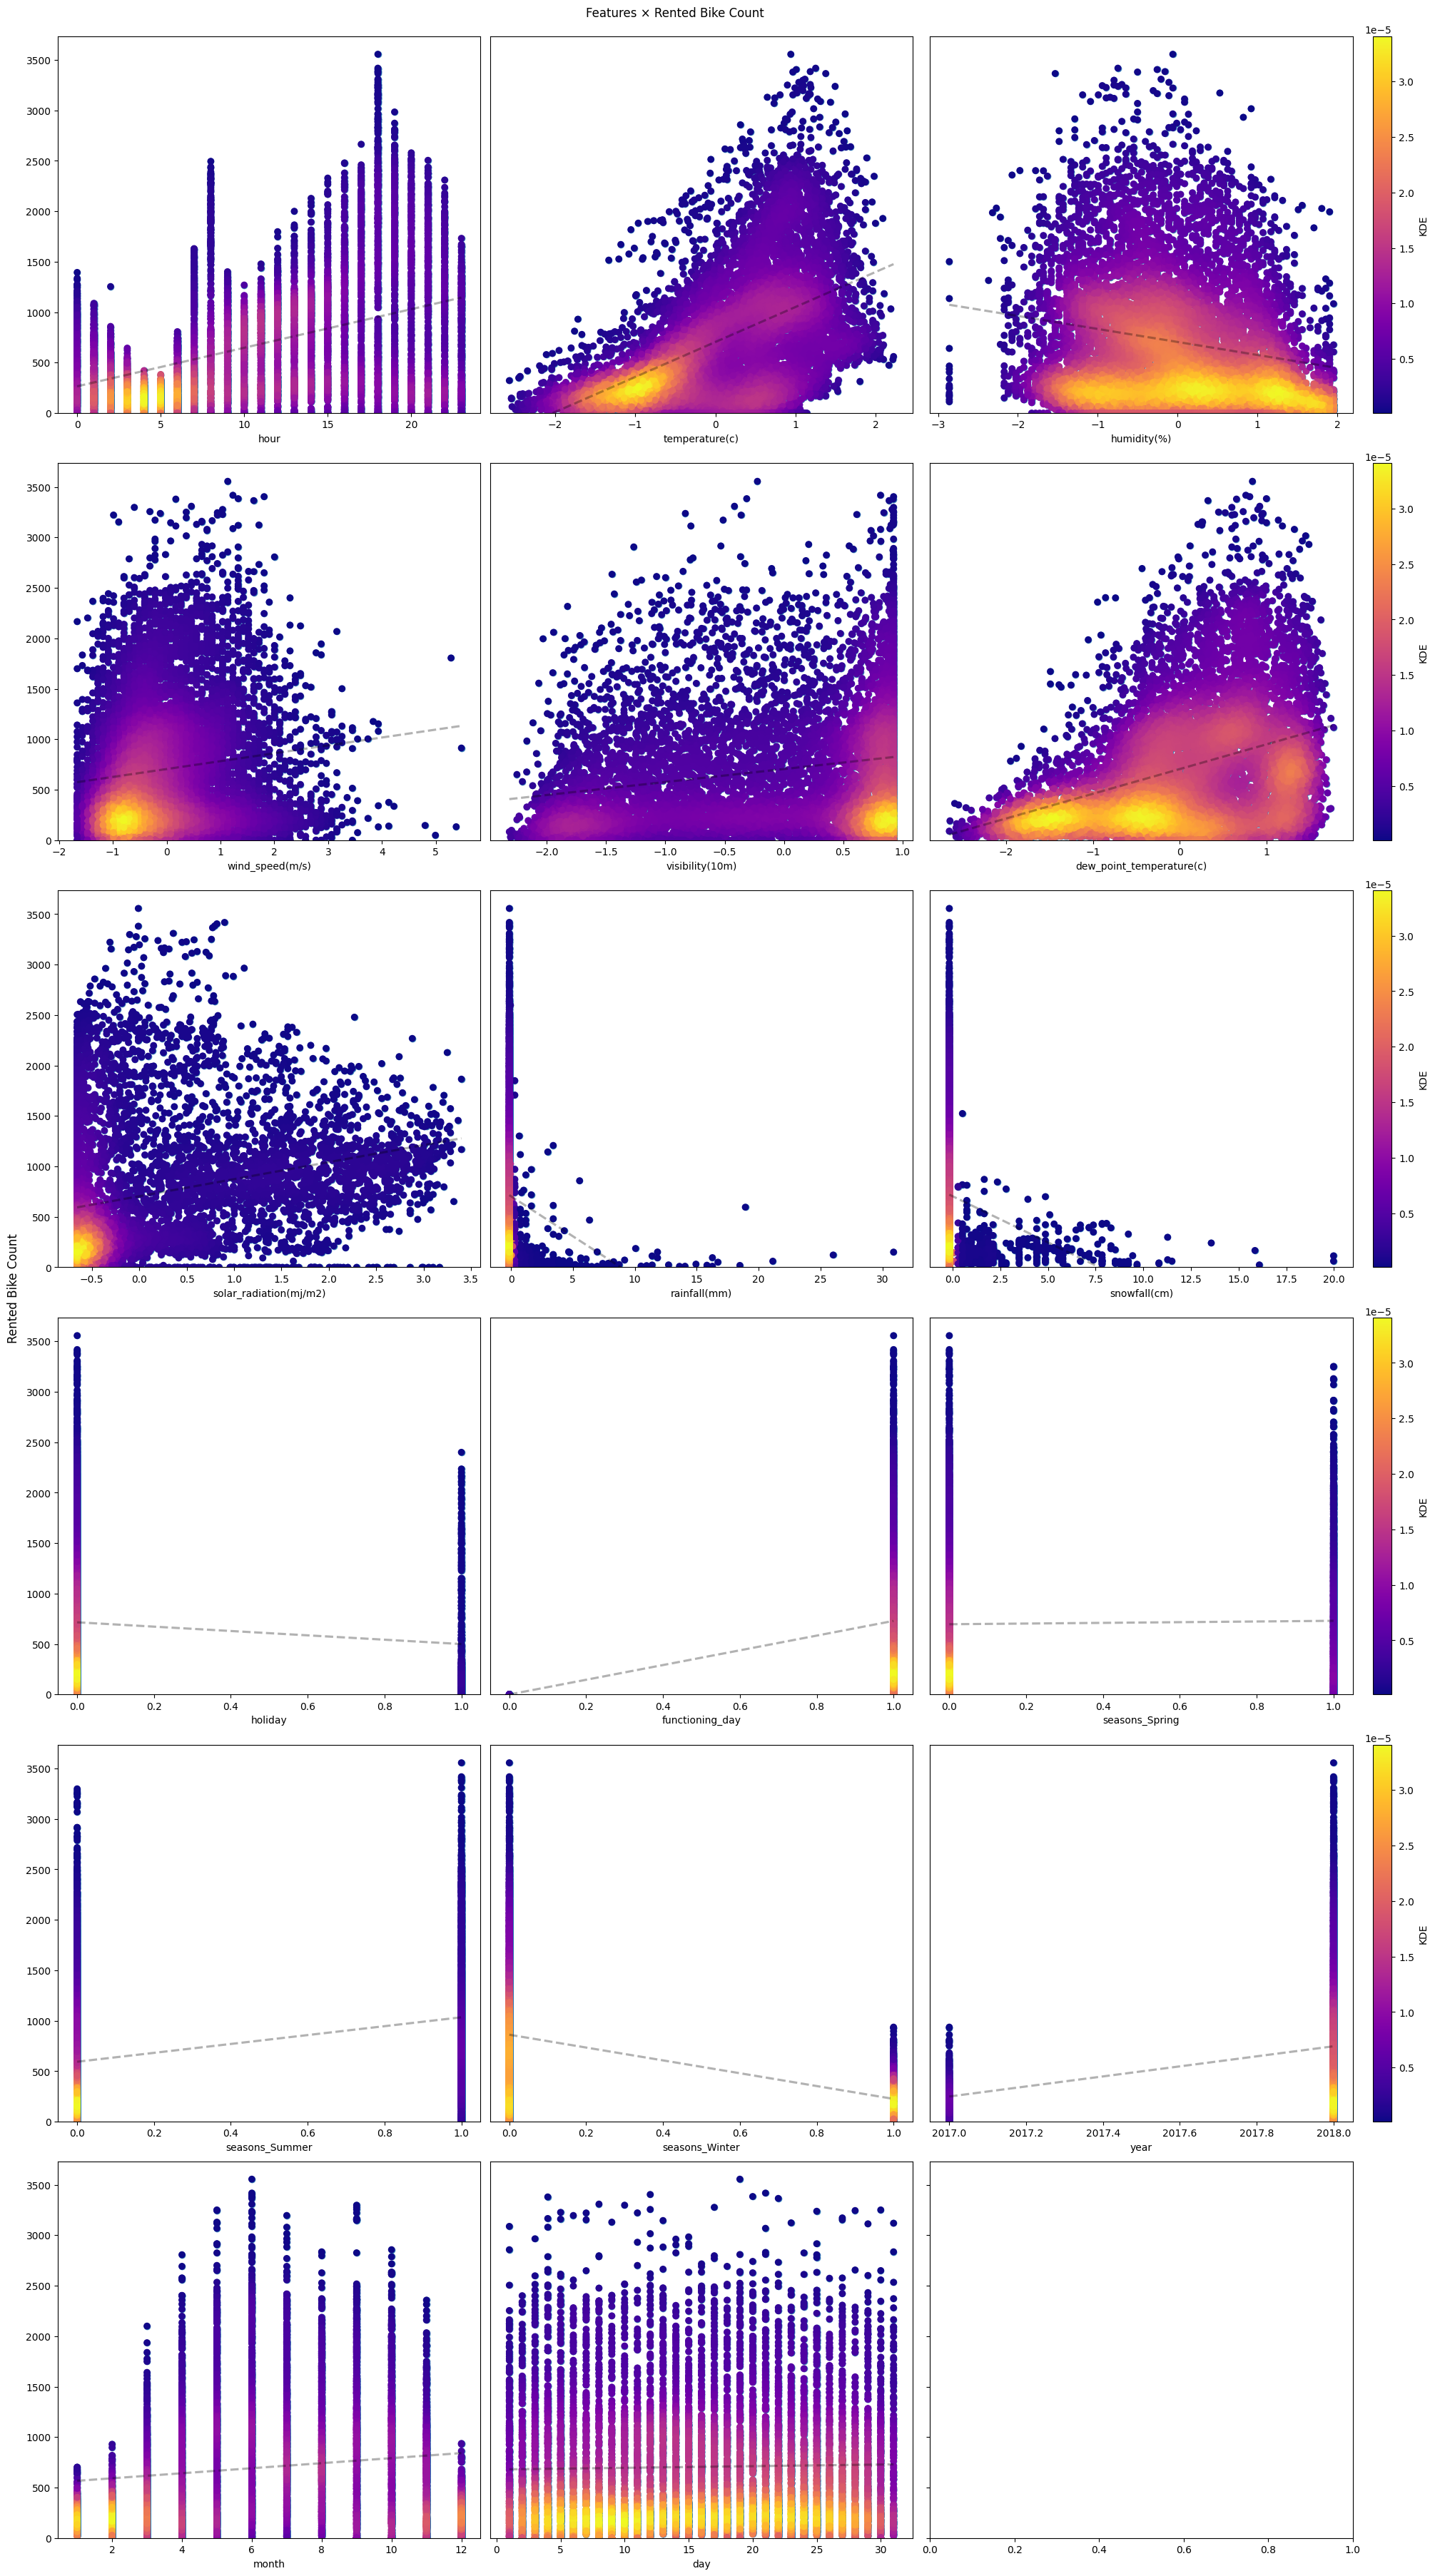

In [68]:
# plot some graphs of features modeled against rented_bike_count
from scipy.stats import gaussian_kde
from math import ceil
import matplotlib
print(matplotlib.__version__)
print(sns.__version__)
df = scaled_fbr_df.copy().drop(columns=['rented_bike_count'])
y = scaled_fbr_df['rented_bike_count']

caxy = 0
caxx = 0
height = ceil(len(df.columns)/3)
sub_fig, axs = plt.subplots(height,3, sharey=True, figsize=(20,6*height), constrained_layout=True)
counter = 0
lkws = {'color':'black', 'linestyle':'--', 'alpha':0.3}
cbax = []
for ax, col in zip(axs.flatten(), df.columns):
    df_x = df[col]
    xy = np.vstack([df_x, y])
    dens = gaussian_kde(xy)(xy)
    g = sns.regplot(x=df_x,y=y,ci=False, ax=ax, line_kws=lkws, label='Trend Line')
    g.set(ylim=(0,None))
    plot_scat = ax.scatter(df_x, y, c=dens, cmap='plasma')
    ax.set_xlabel(col)
    ax.set_ylabel('')
    if counter and counter % 3 != 0:
        ax.tick_params(axis='y', which='both', left=False, right=False)
    if counter and (counter+1) % 3 == 0:
        cbax.append(ax)
    counter += 1
    
sub_fig.suptitle('Features × Rented Bike Count', x=0.47, ha='center')
sub_fig.supylabel('Rented Bike Count')
# axs[1].legend(loc='upper left')
for ax in cbax:
    plt.colorbar(plot_scat, ax=ax, pad=0.01, label='KDE')
plt.show()

In [69]:
lin_model = LinearRegression()
rid_model = Ridge(alpha=1.0)
las_model = Lasso(alpha=0.1)
ela_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
dtr_model = DecisionTreeRegressor(max_depth=5, random_state=691)
# Array of models for ease of looping
models = [lin_model, rid_model, las_model, ela_model, dtr_model]
# Fit all models and print their coefficients if applicable
for model in models:
    X = scaled_fbr_df.drop(columns=['rented_bike_count'])
    y = scaled_fbr_df['rented_bike_count']
    model.fit(X, y)
    print(f"\nModel: {model.__class__.__name__}")
    if hasattr(model, 'coef_'):
        print("Coefficients:", model.coef_)
    if hasattr(model, 'intercept_'):
        print("Intercept:", model.intercept_)


Model: LinearRegression
Coefficients: [  27.3171636   200.10408109 -224.65513062   20.1262245     4.28175277
  142.01780908  -70.65509267  -64.45758895   14.70456536 -127.15074385
  936.36146795 -394.26402956 -286.51580452 -760.63424913 -539.84631515
  -43.04935818   -1.13195662]
Intercept: 1089513.7941147776

Model: Ridge
Coefficients: [  27.32908285  200.37981329 -224.0917146    20.05008709    4.42807851
  141.38534417  -70.43982519  -64.5500493    14.62279498 -126.62477538
  932.25007028 -374.36567262 -275.81196408 -732.1863409  -505.44863719
  -39.93570921   -1.1205095 ]
Intercept: 1020070.7836794183

Model: Lasso
Coefficients: [  27.35215993  203.97158883 -221.5944828    19.83634985    4.47984165
  135.83019857  -70.07638092  -64.60870826   14.39305787 -124.33227709
  931.76257043 -359.68216323 -266.78057796 -712.52072909 -479.94378004
  -37.60400831   -1.1139973 ]
Intercept: 968578.0951337673

Model: ElasticNet
Coefficients: [ 2.87177345e+01  1.98539007e+02 -1.73012192e+02  1.17